# TP2 : Calibration de Caméra

### Objectif
Comprendre le modèle géométrique d'une caméra et estimer :
- Les **paramètres intrinsèques** (matrice K)
- Les **paramètres extrinsèques** (rvecs, tvecs)
- Les **coefficients de distorsion**

In [304]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

- `CHESSBOARD_SIZE` : nombre de **coins intérieurs** (pas de carrés) — un damier 10×7 carrés → `(9, 6)`
- `SQUARE_SIZE_CM` : taille d'un carré du damier
- `image_paths` : dossier contenant les photos

In [305]:
CHESSBOARD_SIZE = (9, 6)
SQUARE_SIZE_CM  = 2.5
image_paths     = sorted(glob.glob('Images/imgs/*.jpg'))
SUBPIX_CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

---
## Partie 1 : Détection des coins du damier

### 1.1 Chargement et conversion en niveaux de gris

13 image(s) trouvée(s) dans 'Images/'


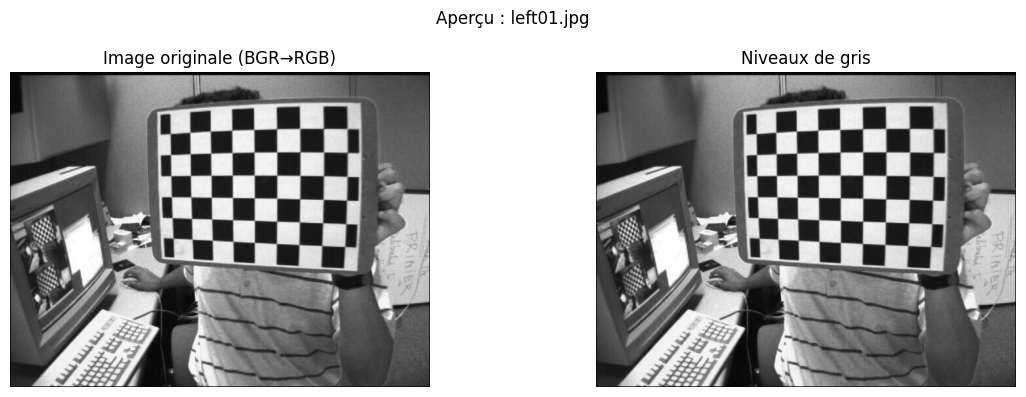

Taille de l'image : 640×480 px


In [306]:
print(f"{len(image_paths)} image(s) trouvée(s) dans 'Images/'")

if len(image_paths) == 0:
    print("Aucune image trouvée ! Vérifiez vos images et le chemin d'accès.")
else:
    # Aperçu de la première image
    sample = cv2.imread(image_paths[0])
    sample_gray = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Image originale (BGR→RGB)")
    axes[0].axis("off")
    axes[1].imshow(sample_gray, cmap="gray")
    axes[1].set_title("Niveaux de gris")
    axes[1].axis("off")
    plt.suptitle(f"Aperçu : {os.path.basename(image_paths[0])}", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Taille de l'image : {sample.shape[1]}×{sample.shape[0]} px")

### 1.3 Détection des coins 2D dans chaque image

In [307]:
# Points 3D (monde réel) — défini une seule fois
objp = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD_SIZE[0], 0:CHESSBOARD_SIZE[1]].T.reshape(-1, 2) * SQUARE_SIZE_CM

obj_points = []  # coordonnées 3D
img_points = []  # coordonnées 2D

for path in image_paths:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHESSBOARD_SIZE, None)
    if ret:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), SUBPIX_CRITERIA)
        obj_points.append(objp)
        img_points.append(corners)
        print(f"\n{path.split('/')[-1]} — coordonnées 2D :\n", corners[:3].reshape(-1, 2))


imgs\left01.jpg — coordonnées 2D :
 [[244.40527   94.136856]
 [274.3947    92.21057 ]
 [305.50098   90.3172  ]]

imgs\left02.jpg — coordonnées 2D :
 [[256.43854 362.37518]
 [255.23814 334.4244 ]
 [254.30472 308.90814]]

imgs\left03.jpg — coordonnées 2D :
 [[277.1963   72.20096]
 [313.96414  81.24666]
 [353.019    91.03333]]

imgs\left04.jpg — coordonnées 2D :
 [[188.52176 130.59633]
 [223.2543  127.10605]
 [260.33713 123.72382]]

imgs\left05.jpg — coordonnées 2D :
 [[436.27338   49.716278]
 [448.9563    77.81586 ]
 [462.56415  108.73792 ]]

imgs\left06.jpg — coordonnées 2D :
 [[588.92096 138.74245]
 [586.09515 175.47713]
 [582.7455  212.21744]]

imgs\left07.jpg — coordonnées 2D :
 [[368.9847  137.5897 ]
 [358.26236 169.28902]
 [347.21115 201.87798]]

imgs\left08.jpg — coordonnées 2D :
 [[470.81134   92.58327 ]
 [465.25787  126.090904]
 [459.14886  162.35391 ]]

imgs\left09.jpg — coordonnées 2D :
 [[219.09511   85.662674]
 [263.2033    93.23341 ]
 [305.20047  100.85406 ]]

imgs\left11.

### Coordonnées 3D des coins (monde réel)

On suppose le damier **plat sur le plan Z = 0**. Les coins sont espacés de `SQUARE_SIZE_CM`.

In [308]:
# Le damier est plat (Z=0), les coins sont espacés de SQUARE_SIZE_CM
objp = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD_SIZE[0], 0:CHESSBOARD_SIZE[1]].T.reshape(-1, 2) * SQUARE_SIZE_CM

print("Points 3D :\n", objp[:5])

Points 3D :
 [[ 0.   0.   0. ]
 [ 2.5  0.   0. ]
 [ 5.   0.   0. ]
 [ 7.5  0.   0. ]
 [10.   0.   0. ]]


### 1.4 Affichage des coins détectés

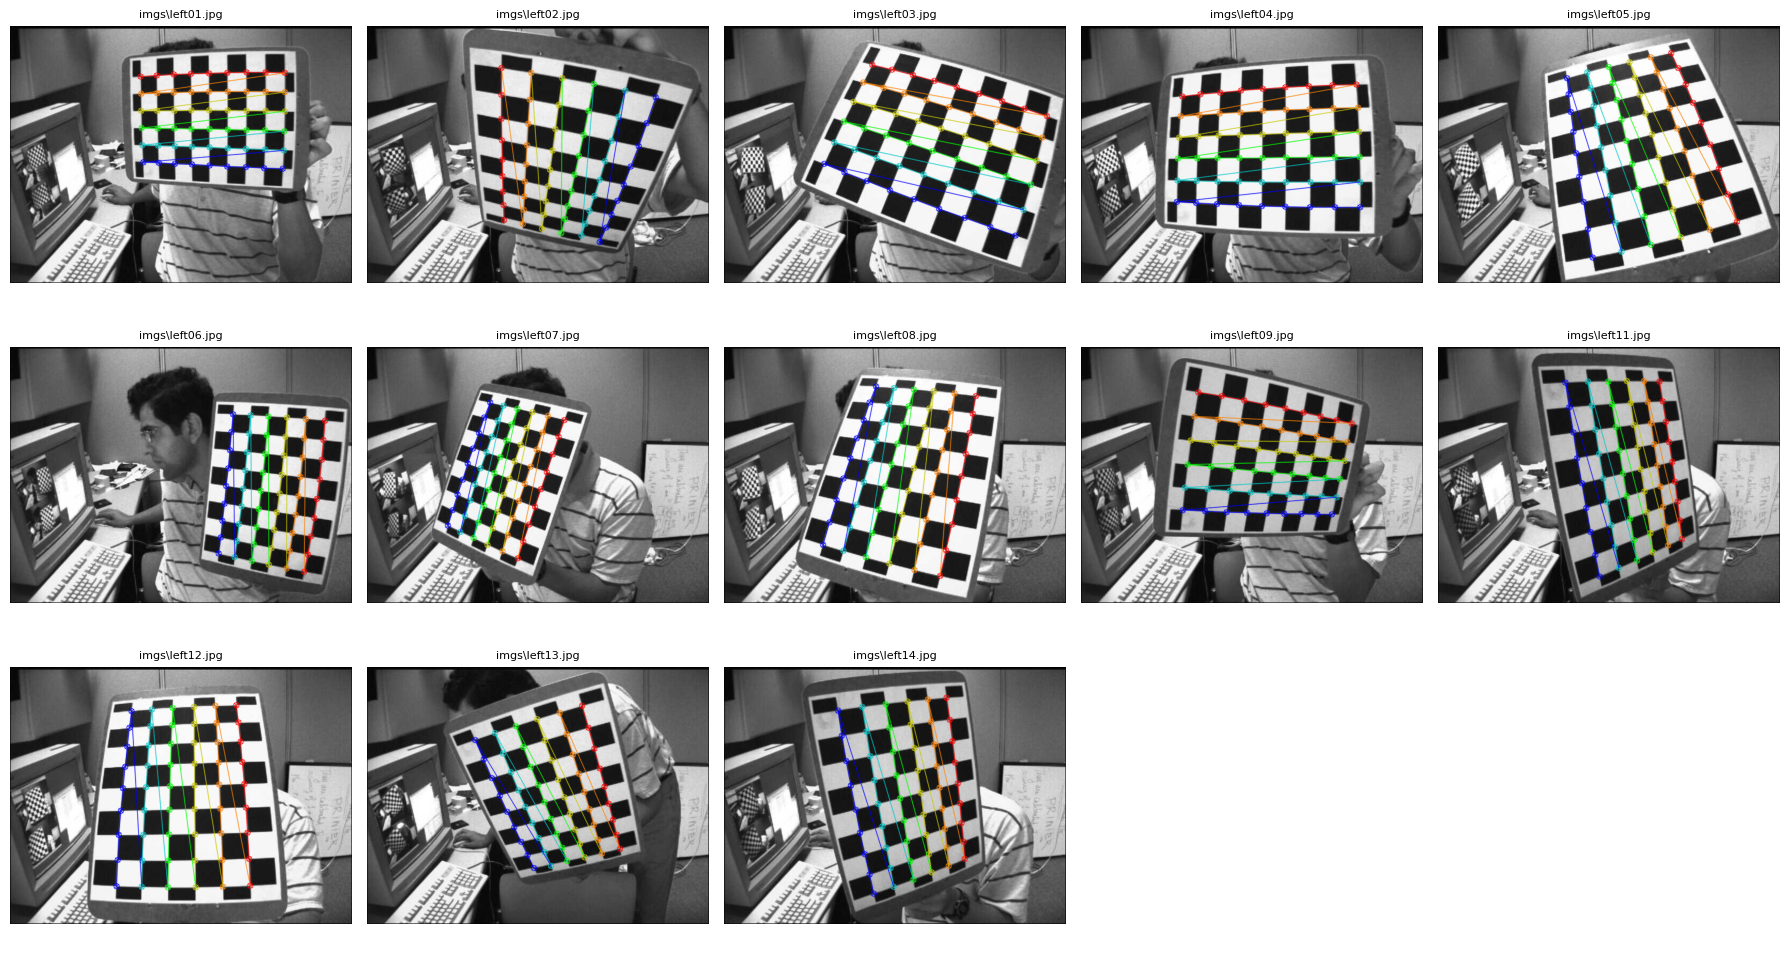

In [309]:
valid_images = []

for path in image_paths:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHESSBOARD_SIZE, None)
    if ret:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), SUBPIX_CRITERIA)
        obj_points.append(objp)
        img_points.append(corners)
        img_drawn = img.copy()
        cv2.drawChessboardCorners(img_drawn, CHESSBOARD_SIZE, corners, ret)
        valid_images.append((path, img_drawn))

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, (path, img_drawn) in enumerate(valid_images):
    axes[i].imshow(cv2.cvtColor(img_drawn, cv2.COLOR_BGR2RGB))
    axes[i].set_title(path.split('/')[-1], fontsize=8)
    axes[i].axis('off')

for j in range(len(valid_images), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

---
## Partie 2 : Calibration

### 2.1 Calibration via `cv2.calibrateCamera()`

In [ ]:
print("objectPoints — shape d'une entrée :", obj_points[0].shape)
print("imagePoints  — shape d'une entrée :", img_points[0].shape)

objectPoints — shape d'une entrée : (54, 3)
imagePoints  — shape d'une entrée : (54, 1, 2)


In [311]:
h, w = cv2.imread(image_paths[0]).shape[:2]

rms, K_cv, dist_cv, rvecs, tvecs = cv2.calibrateCamera(
    obj_points, img_points, (w, h), None, None
)

print(f"RMS : {rms:.4f} px")
print("\nMatrice intrinsèque K :")
print(K_cv)
print("\nCoefficients de distorsion :")
print(dist_cv)
print("\nParamètres extrinsèques (première image) :")
print("rvec :", rvecs[0].T)
print("tvec :", tvecs[0].T)

RMS : 0.4087 px

Matrice intrinsèque K :
[[536.07345314   0.         342.37046827]
 [  0.         536.01636274 235.53687064]
 [  0.           0.           1.        ]]

Coefficients de distorsion :
[[-0.26509039 -0.0467422   0.00183302 -0.00031469  0.25231221]]

Paramètres extrinsèques (première image) :
rvec : [[0.16853574 0.27575303 0.01346808]]
tvec : [[ -7.52796975 -10.89391798  39.98218179]]


`rms` → Root Mean Square error, l’erreur moyenne entre ce que la caméra “voit” et ce qu’elle devrait voir. Plus c’est petit, mieux c’est.

`K_cv` → matrice intrinsèque de la caméra. Contient le focale fx, fy et le centre cx, cy. En gros, ça dit comment la caméra transforme le monde 3D en image 2D.

`dist_cv` → coefficients de distorsion (barrel, pincushion, etc.). Ça permet de corriger les courbures causées par l’objectif.

`rvecs et tvecs` → paramètres extrinsèques pour chaque image : rotation et translation qui disent comment la caméra était positionnée par rapport au motif de calibration

---------------------------------------------------------------------------------------------------

### 2.2 Méthode linéaire de Zhang (SVD)

On recalcule K **from scratch** selon la méthode de Zhang :
1. Calcul des homographies H pour chaque vue
2. Construction du système **Vb = 0** (contraintes sur la matrice B = K⁻ᵀK⁻¹)
3. Résolution par **SVD** → extraction de K

In [ ]:
def compute_homographies(obj_points, img_points):
    homographies = []
    for objp, imgp in zip(obj_points, img_points):
        src = objp[:, :2].astype(np.float32)           # coords monde (X, Y)
        dst = imgp.reshape(-1, 2).astype(np.float32)   # coords image (u, v)
        H, _ = cv2.findHomography(src, dst)
        homographies.append(H)
    return homographies

homographies = compute_homographies(obj_points, img_points)
print(f"{len(homographies)} homographies calculées")
print(f"\nH[0] (première vue) :\n{homographies[0]}")

39 homographies calculées

H[0] (première vue) :
[[ 1.08285676e+01  8.39952039e-01  2.43762942e+02]
 [-7.96299131e-01  1.35098903e+01  9.18042979e+01]
 [-5.33312678e-03  2.08670948e-03  1.00000000e+00]]


Une homographie, notée souvent H, est une matrice 3×3 qui te permet de passer d’un plan à un autre dans une image

In [ ]:
def vij(H, i, j):
    """Vecteur v_ij de la méthode Zhang (indices 0-based)."""
    return np.array([
        H[0, i] * H[0, j],
        H[0, i] * H[1, j] + H[1, i] * H[0, j],
        H[1, i] * H[1, j],
        H[2, i] * H[0, j] + H[0, i] * H[2, j],
        H[2, i] * H[1, j] + H[1, i] * H[2, j],
        H[2, i] * H[2, j],
    ])

V = []
for H in homographies:
    V.append(vij(H, 0, 1))           # v_01 = 0
    V.append(vij(H, 0, 0) - vij(H, 1, 1))  # v_00 - v_11 = 0
V = np.array(V)   # shape : (2n, 6)

print(f"Matrice V : {V.shape}  (2×{len(homographies)} équations, 6 inconnues)")

Matrice V : (78, 6)  (2×39 équations, 6 inconnues)


In [314]:
# ── Étape 3 : SVD → b → K ───────────────────────────────────
_, S, Vt = np.linalg.svd(V)
b = Vt[-1]   # vecteur propre associé à la plus petite valeur singulière

print(f"Valeurs singulières : {S}")
print(f"\nVecteur b : {b}")

# Extraction de K depuis b = [B11, B12, B22, B13, B23, B33]
B11, B12, B22, B13, B23, B33 = b

v0  = (B12 * B13 - B11 * B23) / (B11 * B22 - B12**2)
lam = B33 - (B13**2 + v0 * (B12 * B13 - B11 * B23)) / B11
fx  = np.sqrt(lam / B11)
fy  = np.sqrt(lam * B11 / (B11 * B22 - B12**2))
s   = -B12 * fx**2 * fy / lam
u0  = s * v0 / fy - B13 * fx**2 / lam

K_zh = np.array([
    [fx,  s, u0],
    [0., fy, v0],
    [0.,  0.,  1.]
])

print("\nMatrice intrinsèque K (Zhang SVD) :")
print(K_zh)

Valeurs singulières : [2.05708689e+03 2.00577649e+03 4.98360006e+02 1.86390089e+00
 1.02432436e+00 1.25529377e-04]

Vecteur b : [ 2.07415631e-06  7.41029362e-09  2.06665219e-06 -7.35834201e-04
 -4.88689931e-04  9.99999610e-01]

Matrice intrinsèque K (Zhang SVD) :
[[548.77189439  -1.96415439 353.92285923]
 [  0.         549.77082245 235.19548182]
 [  0.           0.           1.        ]]


---------------------------------------------------------------------------------------------------

### 2.3 Comparaison K_OpenCV vs K_Zhang

In [315]:
print("K (OpenCV) :")
print(K_cv)
print("\nK (Zhang) :")
print(K_zh)
print(f"\nNorme de la différence : {np.linalg.norm(K_cv - K_zh):.4f}")

K (OpenCV) :
[[536.07345314   0.         342.37046827]
 [  0.         536.01636274 235.53687064]
 [  0.           0.           1.        ]]

K (Zhang) :
[[548.77189439  -1.96415439 353.92285923]
 [  0.         549.77082245 235.19548182]
 [  0.           0.           1.        ]]

Norme de la différence : 22.0877


---
## Partie 3 : Correction de distorsion

### 3.1 Photo du téléphone

In [316]:
CHESSBOARD_SIZE = (9, 6)
SQUARE_SIZE_CM  = 2.5
image_paths_phone = sorted(glob.glob('Images/imgs_phone/*.jpg'))
SUBPIX_CRITERIA = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

6 image(s) trouvée(s) dans 'Images/'


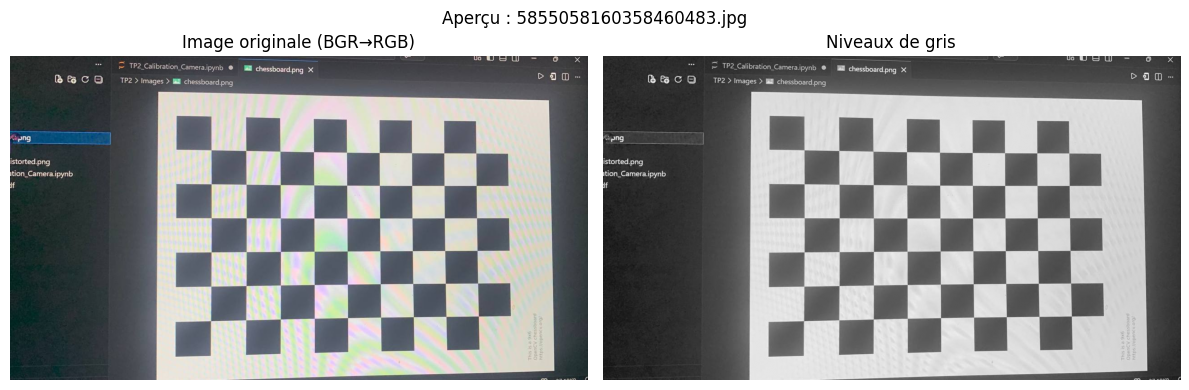

Taille de l'image : 1280×719 px


In [317]:
print(f"{len(image_paths_phone)} image(s) trouvée(s) dans 'Images/'")

if len(image_paths_phone) == 0:
    print("Aucune image trouvée ! Vérifiez vos images et le chemin d'accès.")
else:
    # Aperçu de la première image
    sample = cv2.imread(image_paths_phone[0])
    sample_gray = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Image originale (BGR→RGB)")
    axes[0].axis("off")
    axes[1].imshow(sample_gray, cmap="gray")
    axes[1].set_title("Niveaux de gris")
    axes[1].axis("off")
    plt.suptitle(f"Aperçu : {os.path.basename(image_paths_phone[0])}", fontsize=12)
    plt.tight_layout()
    plt.show()
    print(f"Taille de l'image : {sample.shape[1]}×{sample.shape[0]} px")

In [318]:
# Points 3D (monde réel) — défini une seule fois
objp = np.zeros((CHESSBOARD_SIZE[0] * CHESSBOARD_SIZE[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD_SIZE[0], 0:CHESSBOARD_SIZE[1]].T.reshape(-1, 2) * SQUARE_SIZE_CM

obj_points = []  # coordonnées 3D
img_points = []  # coordonnées 2D

for path in image_paths_phone:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHESSBOARD_SIZE, None)
    if ret:
        corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), SUBPIX_CRITERIA)
        obj_points.append(objp)
        img_points.append(corners)
        print(f"\n{path.split('/')[-1]} — coordonnées 2D :\n", corners[:3].reshape(-1, 2))


imgs_phone\5855058160358460483.jpg — coordonnées 2D :
 [[445.83167 210.41676]
 [522.871   211.79707]
 [598.4479  213.36772]]

imgs_phone\5855058160358460484.jpg — coordonnées 2D :
 [[605.706   267.77435]
 [646.8621  275.7942 ]
 [685.40027 283.33835]]

imgs_phone\5855058160358460485.jpg — coordonnées 2D :
 [[618.7158  150.8635 ]
 [651.09546 150.83661]
 [685.71094 150.69933]]

imgs_phone\5855058160358460486.jpg — coordonnées 2D :
 [[512.2593  286.3867 ]
 [566.354   287.9321 ]
 [619.3396  289.43256]]

imgs_phone\5855058160358460487.jpg — coordonnées 2D :
 [[522.1878  274.55197]
 [590.41876 278.46893]
 [657.5573  282.2706 ]]


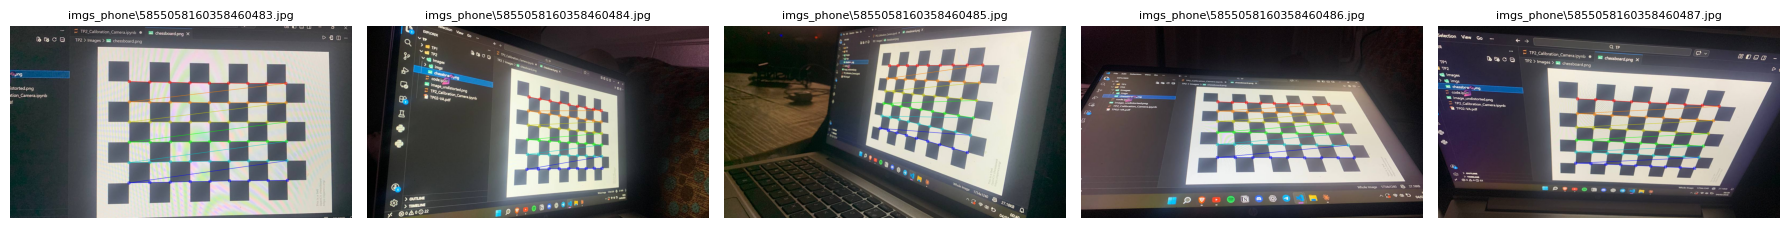

In [ ]:
valid_images = []

for path in image_paths_phone:
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    ret, corners = cv2.findChessboardCorners(gray, CHESSBOARD_SIZE, None)
    if ret:
        corners = cv2.cornerSubPix(gray, corners, (6, 6), (-1, -1), SUBPIX_CRITERIA)
        obj_points.append(objp)
        img_points.append(corners)
        img_drawn = img.copy()
        cv2.drawChessboardCorners(img_drawn, CHESSBOARD_SIZE, corners, ret)
        valid_images.append((path, img_drawn))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, (path, img_drawn) in enumerate(valid_images[:5]):
    axes[i].imshow(cv2.cvtColor(img_drawn, cv2.COLOR_BGR2RGB))
    axes[i].set_title(path.split('/')[-1], fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


### 3.2 Mesure d"un carré

In [320]:
print(f"Taille d'un carré du damier : {SQUARE_SIZE_CM} cm")

Taille d'un carré du damier : 2.5 cm


### 3.2 Correction de la distorsion avec `cv2.undistort()`

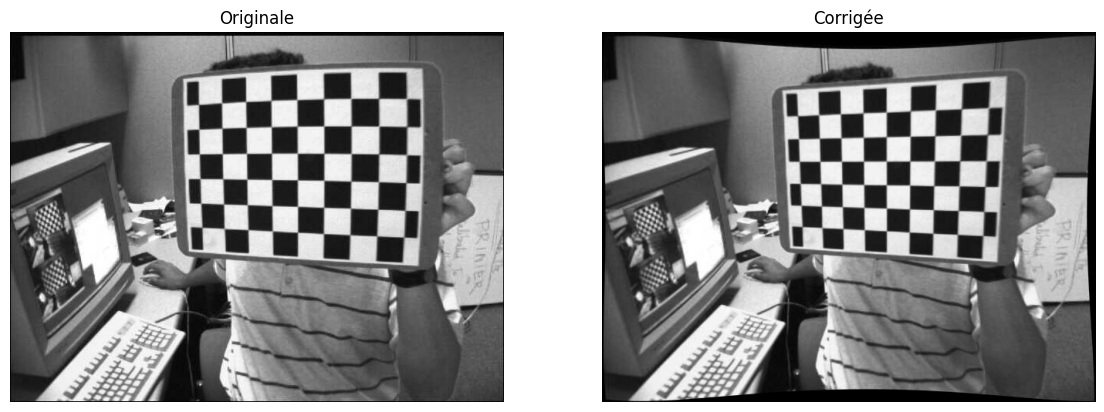

In [321]:
img_raw = cv2.imread(image_paths[0])
h, w = img_raw.shape[:2]

new_K, roi = cv2.getOptimalNewCameraMatrix(K_cv, dist_cv, (w, h), 1)
img_undist = cv2.undistort(img_raw, K_cv, dist_cv, None, new_K)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
ax1.set_title("Originale")
ax1.axis("off")
ax2.imshow(cv2.cvtColor(img_undist, cv2.COLOR_BGR2RGB))
ax2.set_title("Corrigée")
ax2.axis("off")
plt.show()

In [ ]:
# Charger une image brute et corriger la distorsion
raw_path = r"C:\Users\Click\Documents\TPMASTER\VA\Images\photo_2026-03-11_19-46-34.jpg"
img_raw = cv2.imread(raw_path)
if img_raw is None:
    raise FileNotFoundError(f"Image introuvable: {raw_path}")

h, w = img_raw.shape[:2]
new_K, roi = cv2.getOptimalNewCameraMatrix(K_cv, dist_cv, (w, h), 1, (w, h))
img_undist = cv2.undistort(img_raw, K_cv, dist_cv, None, new_K)

# Affichage
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Brute")
plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Corrigee")
plt.imshow(cv2.cvtColor(img_undist, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Matrices
print("Matrice intrins?que K (calibration):")
print(K_cv)
print("
Coefficients de distorsion:")
print(dist_cv)

# Extrinseques pour cette image si damier detecte
ret, corners = cv2.findChessboardCorners(cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY), CHESSBOARD_SIZE, None)
if ret:
    corners = cv2.cornerSubPix(cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY), corners, (11, 11), (-1, -1), SUBPIX_CRITERIA)
    success, rvec, tvec = cv2.solvePnP(objp, corners, K_cv, dist_cv)
    if success:
        R, _ = cv2.Rodrigues(rvec)
        print("
Matrice de rotation R (extrinseque):")
        print(R)
        print("
Vecteur de translation t (extrinseque):")
        print(tvec)
    else:
        print("
solvePnP a echoue. Extrinseques non disponibles.")
else:
    print("
Damier non detecte dans cette image. Extrinseques non disponibles.")
